source:
https://www.kaggle.com/code/greysky/home-credit-baseline

In [10]:
import gc
from glob import glob

import polars as pl
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt


TRAIN_DIR = "data/train"
TEST_DIR = "data/test"
SAMPLE_DIR = "data/sample"

In [11]:
class Pipeline:
    @staticmethod
    def set_table_dtypes(df):
        for col in df.columns:
            if col in ["case_id", "WEEK_NUM", "num_group1", "num_group2"]:
                df = df.with_columns(pl.col(col).cast(pl.Int32))
            elif col in ["date_decision"]:
                df = df.with_columns(pl.col(col).cast(pl.Date))
            elif col[-1] in ("P", "A"):
                df = df.with_columns(pl.col(col).cast(pl.Float64))
            elif col[-1] in ("M",):
                df = df.with_columns(pl.col(col).cast(pl.String))
            elif col[-1] in ("D",):
                df = df.with_columns(pl.col(col).cast(pl.Date))

        return df

    @staticmethod
    def handle_dates(df):
        for col in df.columns:
            if col[-1] in ("D",):
                df = df.with_columns(pl.col(col) - pl.col("date_decision"))
                df = df.with_columns(pl.col(col).dt.total_days())
                df = df.with_columns(pl.col(col).cast(pl.Float32))

        df = df.drop("date_decision", "MONTH")

        return df

    @staticmethod
    def filter_cols(df):
        for col in df.columns:
            if col not in ["target", "case_id", "WEEK_NUM"]:
                isnull = df[col].is_null().mean()

                if isnull > 0.95:
                    df = df.drop(col)

        for col in df.columns:
            if (col not in ["target", "case_id", "WEEK_NUM"]) & (df[col].dtype == pl.String):
                freq = df[col].n_unique()

                if (freq == 1) | (freq > 200):
                    df = df.drop(col)

        return df

In [12]:
class Aggregator:
    @staticmethod
    def num_expr(df):
        cols = [col for col in df.columns if col[-1] in ("P", "A")]

        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]

        return expr_max

    @staticmethod
    def date_expr(df):
        cols = [col for col in df.columns if col[-1] in ("D",)]

        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]

        return expr_max

    @staticmethod
    def str_expr(df):
        cols = [col for col in df.columns if col[-1] in ("M",)]

        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]

        return expr_max

    @staticmethod
    def other_expr(df):
        cols = [col for col in df.columns if col[-1] in ("T", "L")]

        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]

        return expr_max

    @staticmethod
    def count_expr(df):
        cols = [col for col in df.columns if "num_group" in col]

        expr_max = [pl.max(col).alias(f"max_{col}") for col in cols]

        return expr_max

    @staticmethod
    def get_exprs(df):
        exprs = Aggregator.num_expr(df) + \
            Aggregator.date_expr(df) + \
            Aggregator.str_expr(df) + \
            Aggregator.other_expr(df) + \
            Aggregator.count_expr(df)

        return exprs

In [13]:
def read_file(path, depth=None):
    df = pl.read_parquet(path)
    df = df.pipe(Pipeline.set_table_dtypes)

    if depth in [1, 2]:
        df = df.group_by("case_id").agg(Aggregator.get_exprs(df))

    return df


def read_files(regex_path, depth=None):
    chunks = []
    for path in glob(str(regex_path)):
        df = pl.read_parquet(path)
        df = df.pipe(Pipeline.set_table_dtypes)

        if depth in [1, 2]:
            df = df.group_by("case_id").agg(Aggregator.get_exprs(df))

        chunks.append(df)

    df = pl.concat(chunks, how="vertical_relaxed")
    df = df.unique(subset=["case_id"])

    return df

In [14]:
def feature_eng(df_base, depth_0, depth_1, depth_2):
    df_base = (
        df_base
        .with_columns(
            month_decision=pl.col("date_decision").dt.month(),
            weekday_decision=pl.col("date_decision").dt.weekday(),
        )
    )

    for i, df in enumerate(depth_0 + depth_1 + depth_2):
        df_base = df_base.join(df, how="left", on="case_id", suffix=f"_{i}")

    df_base = df_base.pipe(Pipeline.handle_dates)

    return df_base

In [15]:
def to_pandas(df_data, cat_cols=None):
    df_data = df_data.to_pandas()

    if cat_cols is None:
        cat_cols = list(df_data.select_dtypes("object").columns)

    df_data[cat_cols] = df_data[cat_cols].astype("category")

    return df_data, cat_cols

In [16]:
data_store = {
    "df_base": read_file(f"{SAMPLE_DIR}/train_base_sampled.parquet"),
    "depth_0": [
        read_file(f"{SAMPLE_DIR}/train_static_cb_0_sampled.parquet"),
        read_files(f"{SAMPLE_DIR}/train_static_0_*.parquet"),
    ],
    "depth_1": [
        read_files(f"{SAMPLE_DIR}/train_applprev_1_*.parquet", 1),
        read_file(f"{SAMPLE_DIR}/train_tax_registry_a_1_sampled.parquet", 1),
        read_file(f"{SAMPLE_DIR}/train_tax_registry_b_1_sampled.parquet", 1),
        read_file(f"{SAMPLE_DIR}/train_tax_registry_c_1_sampled.parquet", 1),
        read_files(f"{SAMPLE_DIR}/train_credit_bureau_a_1_*.parquet", 1),
        read_file(f"{SAMPLE_DIR}/train_credit_bureau_b_1_sampled.parquet", 1),
        read_file(f"{SAMPLE_DIR}/train_other_1_sampled.parquet", 1),
        read_file(f"{SAMPLE_DIR}/train_person_1_sampled.parquet", 1),
        read_file(f"{SAMPLE_DIR}/train_deposit_1_sampled.parquet", 1),
        read_file(f"{SAMPLE_DIR}/train_debitcard_1_sampled.parquet", 1),
    ],
    "depth_2": [
        read_file(f"{SAMPLE_DIR}/train_credit_bureau_b_2_sampled.parquet", 2),
        read_files(f"{SAMPLE_DIR}/train_credit_bureau_a_2_*.parquet", 2),
    ]
}

df_train = feature_eng(**data_store)
print("train data shape:\t", df_train.shape)

train data shape:	 (99955, 472)


In [17]:
data_store = {
    "df_base": read_file(f"{TEST_DIR}/test_base.parquet"),
    "depth_0": [
        read_file(f"{TEST_DIR}/test_static_cb_0.parquet"),
        read_files(f"{TEST_DIR}/test_static_0_*.parquet"),
    ],
    "depth_1": [
        read_files(f"{TEST_DIR}/test_applprev_1_*.parquet", 1),
        read_file(f"{TEST_DIR}/test_tax_registry_a_1.parquet", 1),
        read_file(f"{TEST_DIR}/test_tax_registry_b_1.parquet", 1),
        read_file(f"{TEST_DIR}/test_tax_registry_c_1.parquet", 1),
        read_files(f"{TEST_DIR}/test_credit_bureau_a_1_*.parquet", 1),
        read_file(f"{TEST_DIR}/test_credit_bureau_b_1.parquet", 1),
        read_file(f"{TEST_DIR}/test_other_1.parquet", 1),
        read_file(f"{TEST_DIR}/test_person_1.parquet", 1),
        read_file(f"{TEST_DIR}/test_deposit_1.parquet", 1),
        read_file(f"{TEST_DIR}/test_debitcard_1.parquet", 1),
    ],
    "depth_2": [
        read_file(f"{TEST_DIR}/test_credit_bureau_b_2.parquet", 2),
        read_files(f"{TEST_DIR}/test_credit_bureau_a_2_*.parquet", 2),
    ]
}

df_test = feature_eng(**data_store)
print("test data shape:\t", df_test.shape)

test data shape:	 (10, 471)


In [18]:
df_train = df_train.pipe(Pipeline.filter_cols)
df_test = df_test.select([col for col in df_train.columns if col != "target"])

print("train data shape:\t", df_train.shape)
print("test data shape:\t", df_test.shape)

train data shape:	 (99955, 364)
test data shape:	 (10, 363)


In [19]:
df_train, cat_cols = to_pandas(df_train)
df_test, cat_cols = to_pandas(df_test, cat_cols)

del data_store
gc.collect()

176

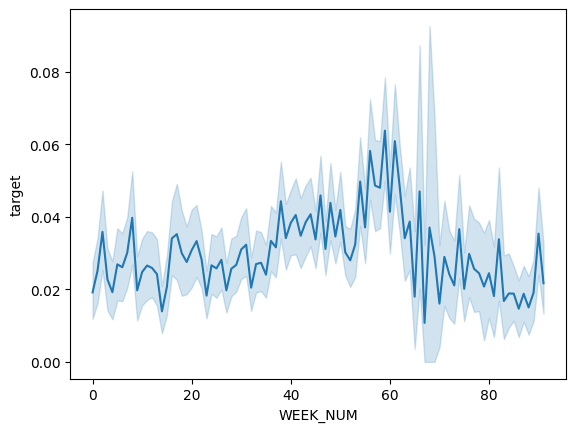

In [20]:
sns.lineplot(
    data=df_train,
    x="WEEK_NUM",
    y="target",
)
plt.show()